The purpose of this notebook is to generate plots comparing the mitchell 2013 data with the rhodes 2013 (2019) data (along with their power spectra).

In [1]:
from methane_noise_forcing import io
from hydra import compose, initialize
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
with initialize(
    version_base=None, config_path="../../configs"
):  # configs with data paths
    cfg = compose(config_name="config")

In [24]:
## plot configs
colors = {
    "wdc05a": "tab:blue",
    "wdc06a": "tab:orange",
    "gisp2": "tab:green",
    "neem": "tab:cyan",
}
plot_kwargs_non_neem = {
    "marker": "o",
    "markersize": 4,
    "linestyle": "None",
}
plot_kwargs_neem = {
    "marker": "o",
    "markersize": 0.1,
    "linestyle": "None",
}
plot_kwargs_site = {
    "wdc05a": plot_kwargs_non_neem,
    "wdc06a": plot_kwargs_non_neem,
    "gisp2": plot_kwargs_non_neem,
    "neem": plot_kwargs_neem,
}
tick_periods = [1000, 500, 200, 100, 50, 20, 10]
tick_periods_site = {
    "wdc05a": tick_periods,
    "wdc06a": [5000, 1000, 500, 200, 100, 50, 20, 10],
    "gisp2": [5000, 1000, 500, 200, 100, 50, 20, 10],
    "neem": [1000, 500, 200, 100, 50, 20, 10, 5, 2, 1],
}

In [4]:
## site names
site_names = ["wdc05a", "wdc06a", "gisp2", "neem"]

## import data and power spectra
data = {}
power_spectra = {}
for site in site_names:
    data[site] = io.load_observational_data(site, **cfg.io[site].input)

    power_spectra[site] = xr.open_dataset(cfg.io[site].power_spectra_path)

# plot obs datasets

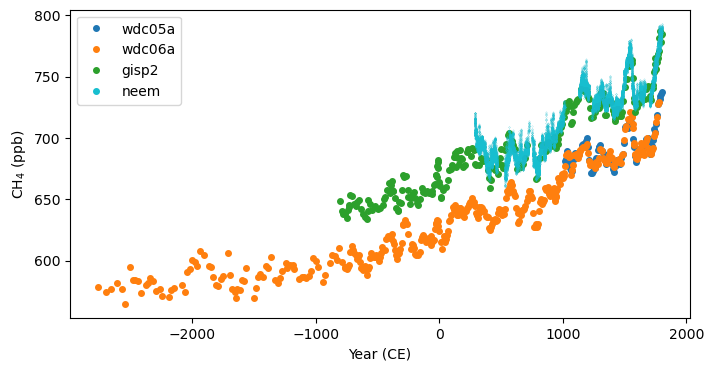

In [5]:
# plot obs datasets
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for site in site_names:
    ax.plot(
        data[site].gas_age,
        data[site].ch4,
        label=site,
        color=colors[site],
        **plot_kwargs_site[site],
    )

ax.set_xlabel("Year (CE)")
ax.set_ylabel("CH$_4$ (ppb)")

legend = ax.legend()
for handle, label in zip(legend.legend_handles, legend.get_texts()):
    if label.get_text() == "neem":
        handle.set_markersize(4)

# power spectra

In [ ]:
## function for plotting power spectra
def plot_power_spectrum(
    ax,
    psd,
    frequencies,
    tick_periods=tick_periods,
    mask_period=0,
    alpha=0.6,
    **plot_kwargs,
):
    mask = 1 / frequencies > mask_period
    ax.plot(
        1 / frequencies[mask],
        psd[mask],
        alpha=alpha,
        **plot_kwargs,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Period (years)")
    ax.set_ylabel("Power Spectral Density (ppb$^2$ year)")
    ax.legend()

    ax.set_xticks(tick_periods)
    ax.set_xticklabels(tick_periods)


## function for fitting power law

## detrended vs raw

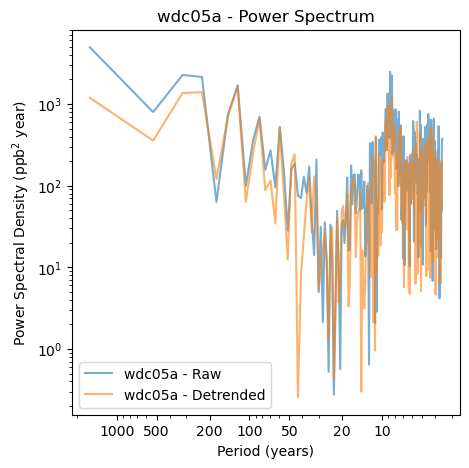

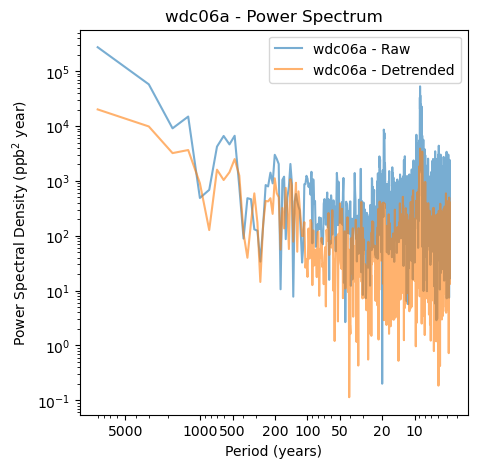

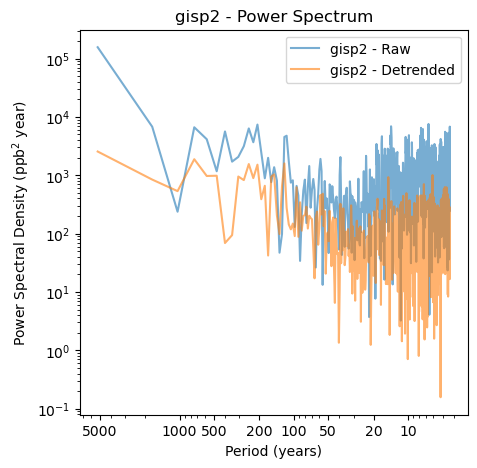

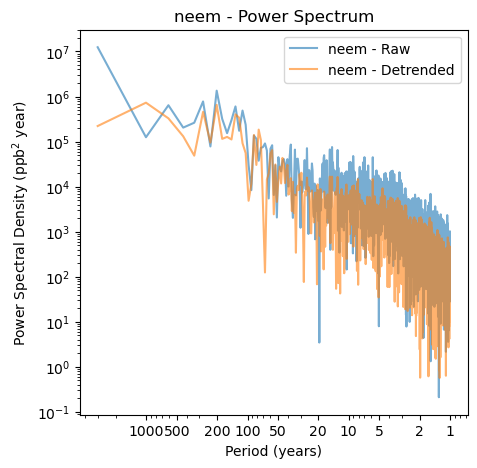

In [25]:
for site in site_names:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    plot_power_spectrum(
        ax,
        psd=power_spectra[site].power_spectrum_raw_unnormalized.values,
        frequencies=power_spectra[site].frequency.values,
        label=f"{site} - Raw",
        tick_periods=tick_periods_site[site],
        mask_period=1,
        color="tab:blue",
    )
    plot_power_spectrum(
        ax,
        psd=power_spectra[site].power_spectrum_detrended_unnormalized.values,
        frequencies=power_spectra[site].frequency.values,
        label=f"{site} - Detrended",
        tick_periods=tick_periods_site[site],
        mask_period=1,
        color="tab:orange",
    )
    ax.invert_xaxis()
    ax.set_title(f"{site} - Power Spectrum")

## compare all sites, raw
Use normalized power spectra to account for different numbers of data points

Text(0, 0.5, 'Power Spectral Density (normalized)')

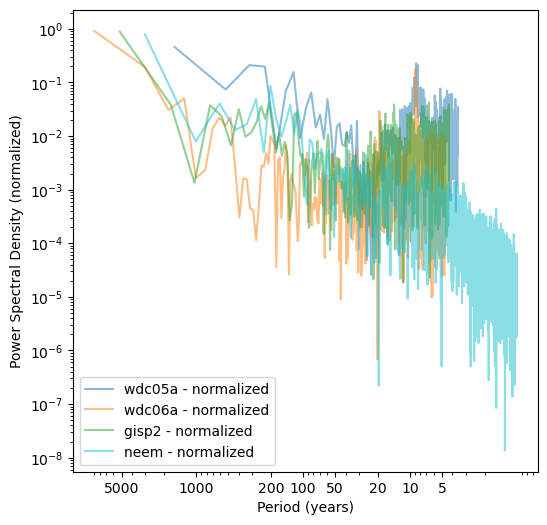

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sites_to_plot = ["wdc05a", "wdc06a", "gisp2", "neem"]

for site in sites_to_plot:
    plot_power_spectrum(
        ax,
        psd=power_spectra[site].power_spectrum_raw_normalized.values,
        frequencies=power_spectra[site].frequency.values,
        label=site,
        mask_period=1,
        alpha=0.5,
        tick_periods=[5000, 1000, 200, 100, 50, 20, 10, 5],
        color=colors[site],
    )

ax.invert_xaxis()
ax.set_ylabel("Power Spectral Density (normalized)")

## compare all sites, detrended

Text(0, 0.5, 'Power Spectral Density (normalized)')

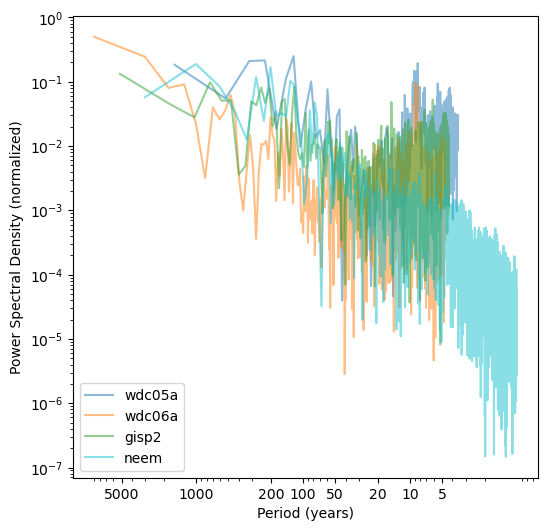

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sites_to_plot = ["wdc05a", "wdc06a", "gisp2", "neem"]
# sites_to_plot = ["neem", "gisp2"]

for site in sites_to_plot:
    plot_power_spectrum(
        ax,
        psd=power_spectra[site].power_spectrum_detrended_normalized.values,
        frequencies=power_spectra[site].frequency.values,
        label=site,
        mask_period=1,
        alpha=0.5,
        tick_periods=[5000, 1000, 200, 100, 50, 20, 10, 5],
        color=colors[site],
    )

ax.invert_xaxis()
ax.set_ylabel("Power Spectral Density (normalized)")